In [1]:
import numpy as np
import periapsis as p
from astropy.table import Table
import matplotlib.pyplot as plt

In [2]:
data_table = Table.read("data/oMEGACat_Data/apjlae7a5ct1_mrt.txt",
                format="ascii.mrt")

clean= ~(data_table['Flag'] > 0)

t = np.asarray(data_table['Year'])[clean]
x = np.asarray(data_table['DeltaRA'])[clean]
y = np.asarray(data_table['DeltaDec'])[clean]
x_err = np.asarray(data_table['e_DeltaRA'])[clean]
y_err = np.asarray(data_table['e_DeltaDec'])[clean]
ref_epoch = 2012
m_vis = 0.78 #solar masses
distance = 5494 #pc


In [3]:
units = {'x':'mas', 'y':'mas', 't':'yr', 'x_err':'mas', 'y_err':'mas', 'M1':'Msun', 'distance':'pc'}
data = p.AstrometryData(t,x,y,x_err,y_err,ref_epoch=ref_epoch,units=units,system='1')

In [4]:
priors = {
    'P':p.UniformPrior(1.2,140),
    'e': p.UniformPrior(0,0.95),
    't0': p.UniformPrior(-0.5,0.5),
    'M1': p.FixedPrior(m_vis),
    'distance': p.FixedPrior(distance)
}

In [5]:
fitter1 = p.UltranestLinearFitter(
    output_params = ['P','e','t0'],
    min_num_live_points = 1000,
    min_ess = 800,
    **priors

)
results1 = fitter1.fit(data)

[ultranest] Sampling 1000 live points from prior ...


[ultranest] Explored until L=-6e+02  .98 [-590.0732..-590.0732]*| it/evals=12240/32508 eff=38.8473% N=1000 
[ultranest] Likelihood function evaluations: 32566
[ultranest]   logZ = -597.7 +- 0.06008
[ultranest] Effective samples strategy satisfied (ESS = 4617.7, need >800)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.05 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.06, need <0.5)
[ultranest]   logZ error budget: single: 0.08 bs:0.06 tail:0.01 total:0.06 required:<0.50
[ultranest] done iterating.


In [6]:
stats, fit_results = p.all_stats(results1,data)

{
    "credible_intervals": {
        "A1": {
            "+1sigma": -0.1458547666206061,
            "+2sigma": 0.1436261600413104,
            "-1sigma": -0.8054614185812967,
            "-2sigma": -1.3534765933786554
        },
        "B1": {
            "+1sigma": -1.3897073560228377,
            "+2sigma": -1.0567336257747522,
            "-1sigma": -2.66098816284986,
            "-2sigma": -3.0628340225258777
        },
        "F1": {
            "+1sigma": 6.389597762413501,
            "+2sigma": 7.612644215098337,
            "-1sigma": 2.9342093999616092,
            "-2sigma": 2.0740713209169197
        },
        "G1": {
            "+1sigma": -0.8540143526949605,
            "+2sigma": -0.6089918769412067,
            "-1sigma": -1.7171657884878926,
            "-2sigma": -2.248212215188854
        },
        "M2": {
            "+1sigma": 5.2006596816548205,
            "+2sigma": 6.657669407417645,
            "-1sigma": 3.3153795652473237,
            "-2sigma": 2.716

/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7096: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7097: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))
/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


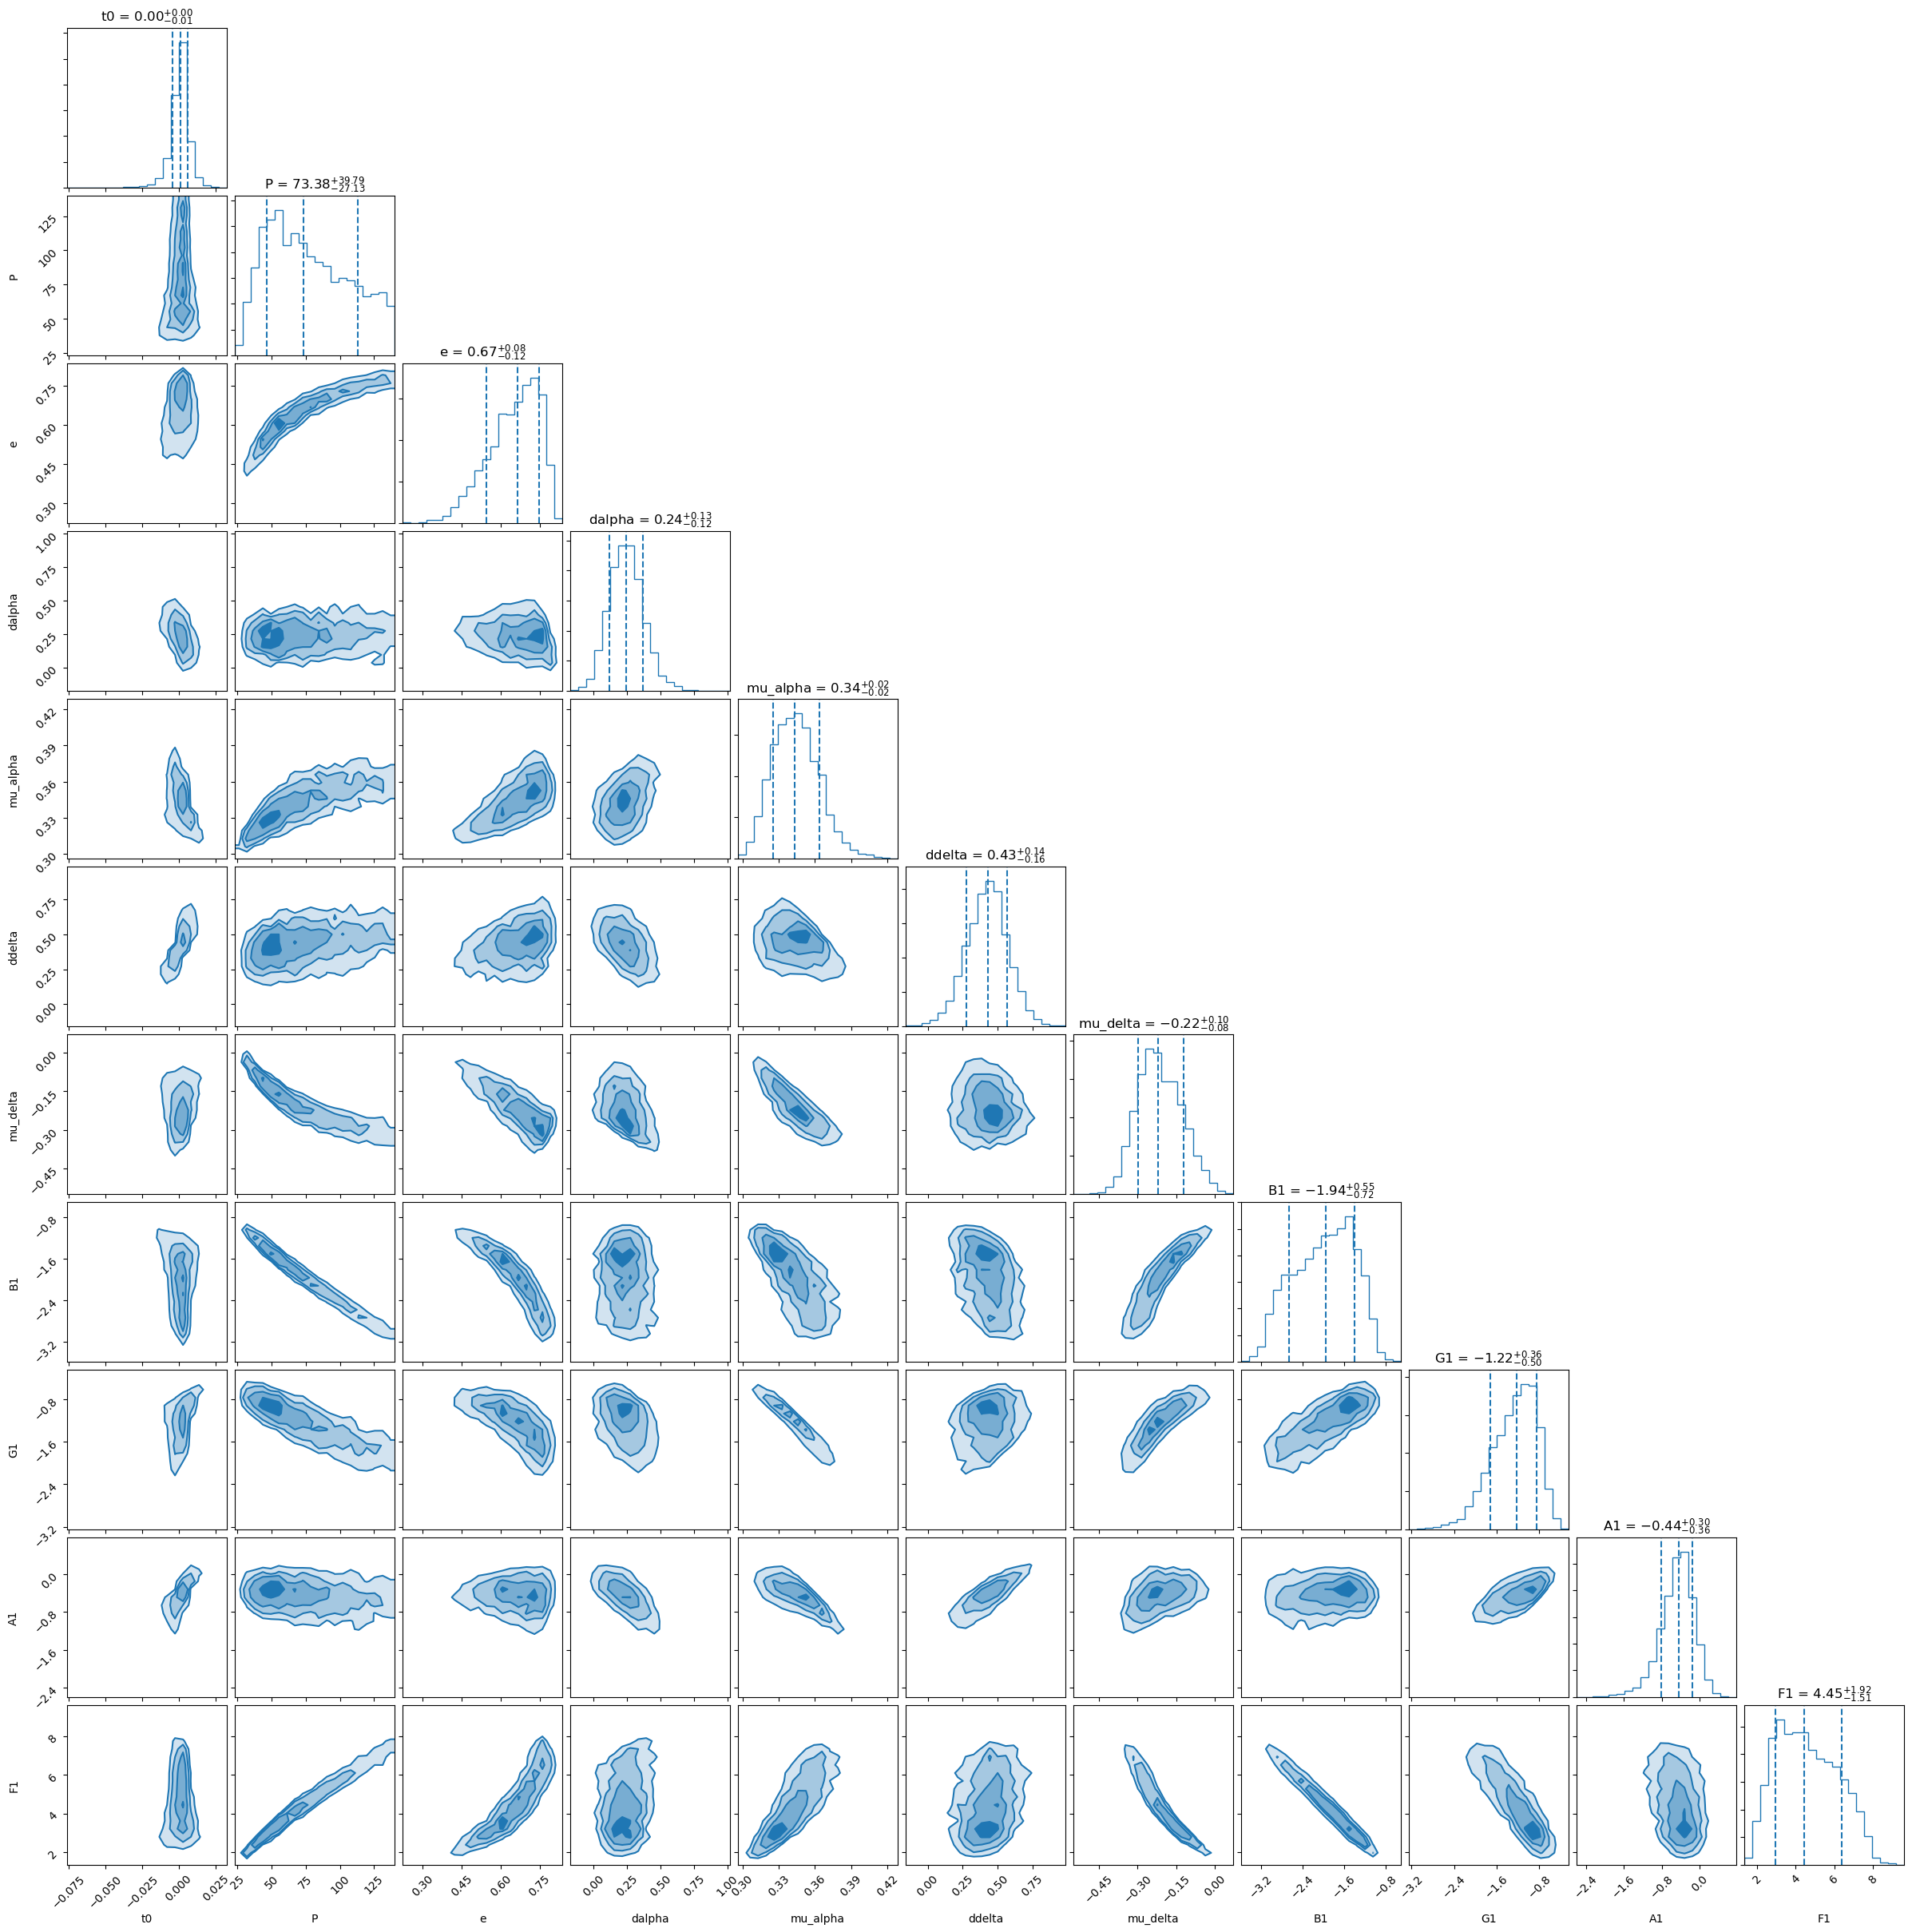

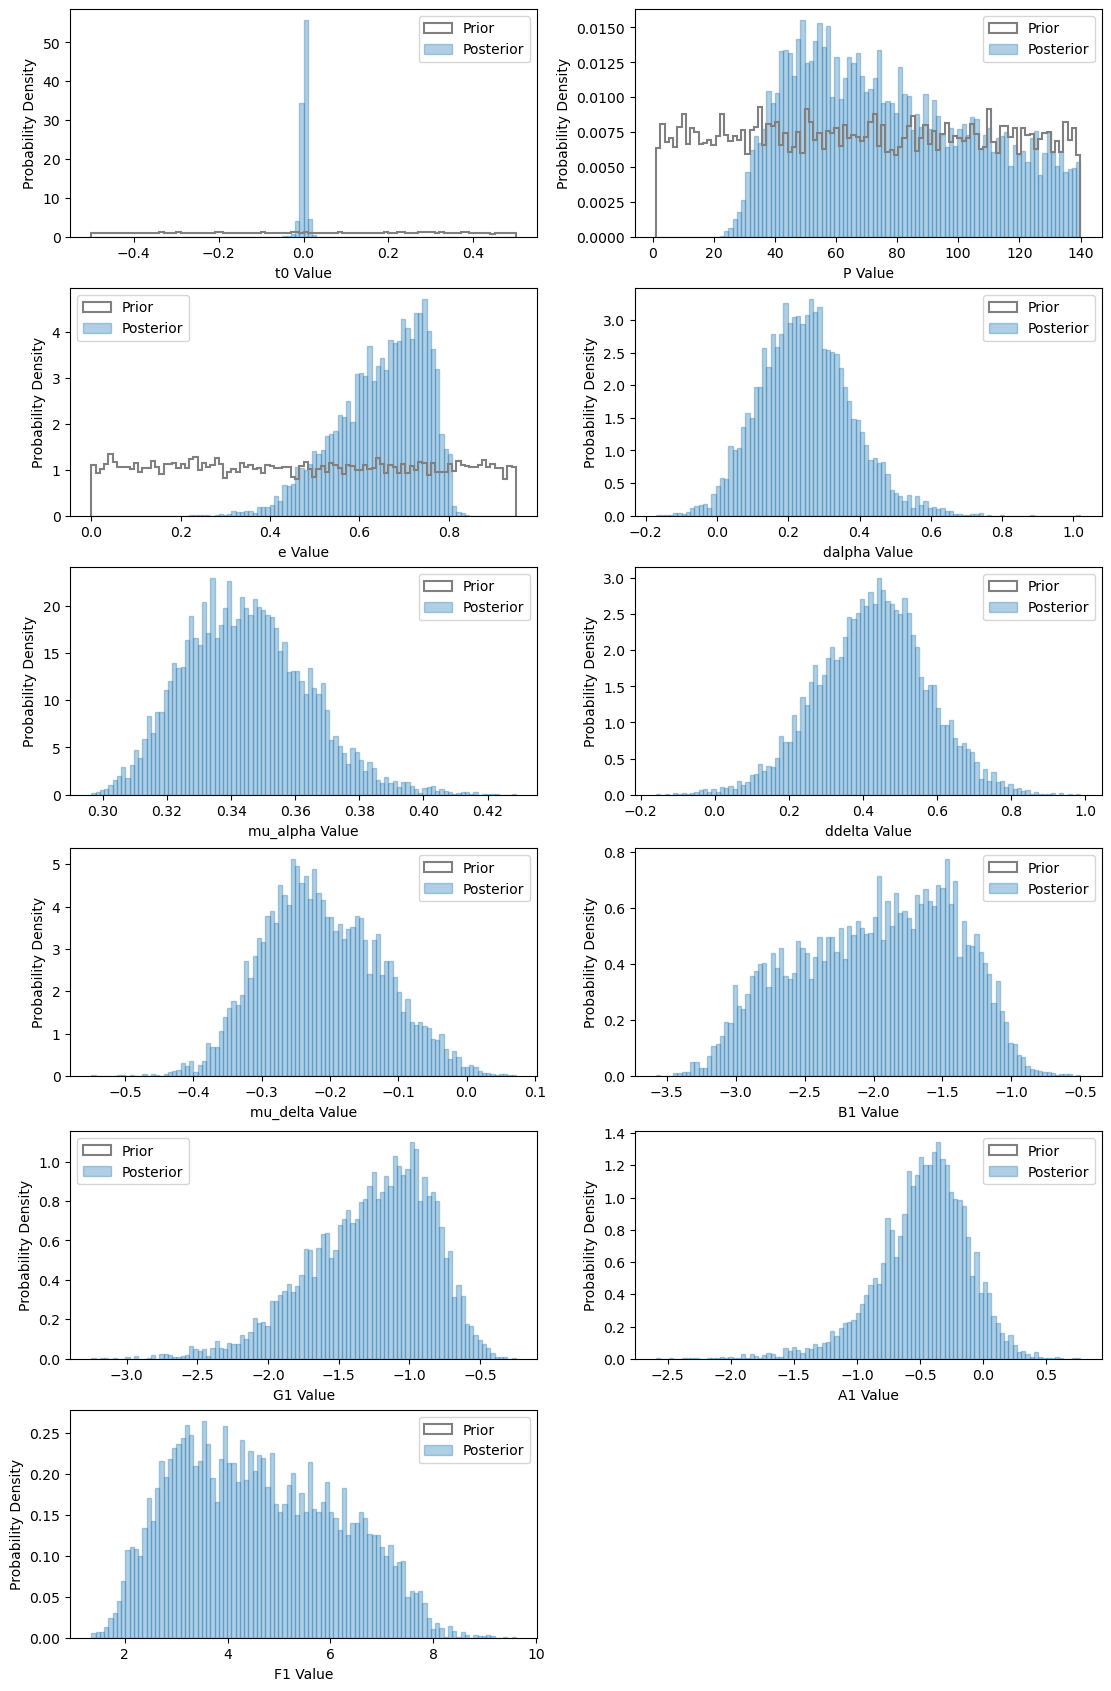

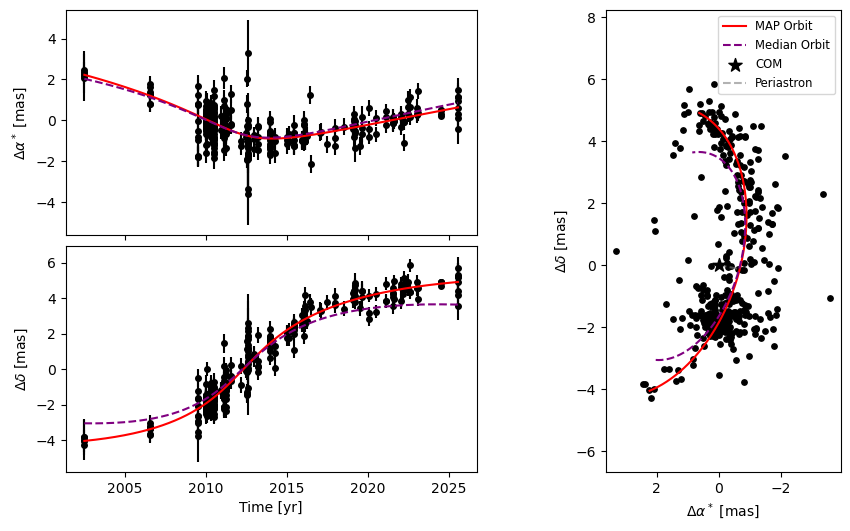

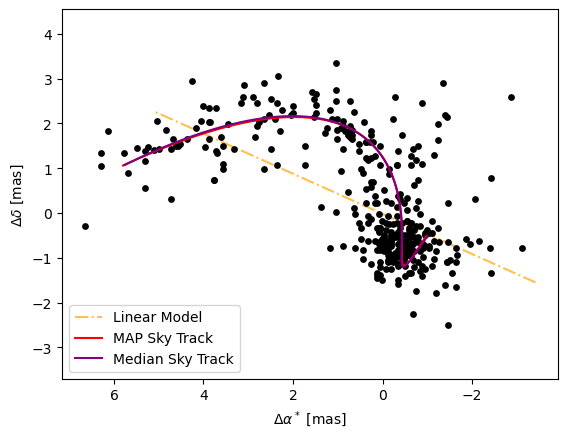

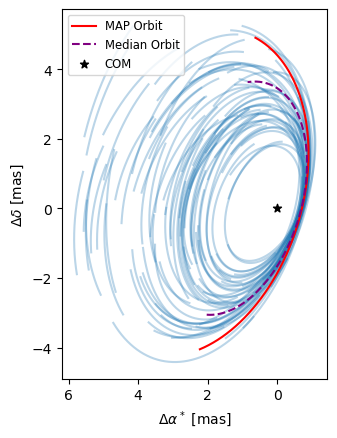

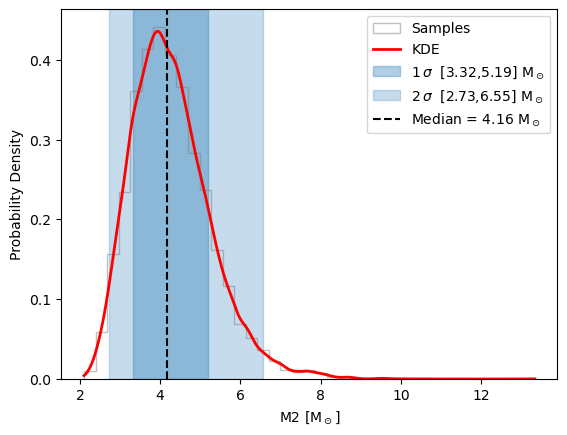

In [7]:
p.all_plots(results1,data)

In [8]:
priors_full = {
    'P':p.UniformPrior(1.2,140),
    'e': p.UniformPrior(0,0.95),
    't0': p.UniformPrior(-0.5,0.5),
    'a1': p.UniformPrior(0.1, 100),
    'cosi': p.UniformPrior(-1,1),
    'omega1': p.UniformPrior(0,2*np.pi),
    'Omega1': p.UniformPrior(0,2*np.pi),
    'M1': p.FixedPrior(m_vis),
    'distance': p.FixedPrior(distance),
    'dalpha': p.UniformPrior(-10,10),
    'ddelta': p.UniformPrior(-10,10),
    'mu_alpha': p.UniformPrior(-10,10),
    'mu_delta': p.UniformPrior(-10,10)
}

In [9]:
fitter2 = p.MCMCFitter(
    nwalkers = 100,
    niter = 50000,
    sample_params = ['P','e','t0','a1','cosi','omega1','Omega1','dalpha','ddelta','mu_alpha','mu_delta'],
    **priors_full
)
results2 = fitter2.fit(data,rng=np.random.default_rng(1234))

100%|██████████| 50000/50000 [20:07<00:00, 41.40it/s]
The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 1000;
tau: [2349.34022653 2462.88969646  887.52205727 2346.08489585 1563.87767525
  694.0120827   983.04728517  505.01142989  678.04553431 1273.94953092
 2326.28309928]


In [10]:
stats2, fit_results2 = p.all_stats(results2,data)

{
    "Ess": [
        2128.2570925858686,
        2030.1355790261277,
        5633.662802010978,
        2131.2101743790367,
        3197.181006626115,
        7204.4855192683535,
        5086.225327555333,
        9900.766010502432,
        7374.13602334812,
        3924.802261493609,
        2149.3514704012077
    ],
    "credible_intervals": {
        "M2": {
            "+1sigma": 5.397006369984963,
            "+2sigma": 6.8748223518259515,
            "-1sigma": 3.326224667706793,
            "-2sigma": 2.672787947055657
        },
        "Omega1": {
            "+1sigma": 2.9125189447515987,
            "+2sigma": 2.9661481772853415,
            "-1sigma": 2.8066516528453564,
            "-2sigma": 2.7440938664555286
        },
        "P": {
            "+1sigma": 120.74731119522104,
            "+2sigma": 136.50976930690828,
            "-1sigma": 49.38322752080952,
            "-2sigma": 32.48506855097531
        },
        "a1": {
            "+1sigma": 6.9270650835776175,

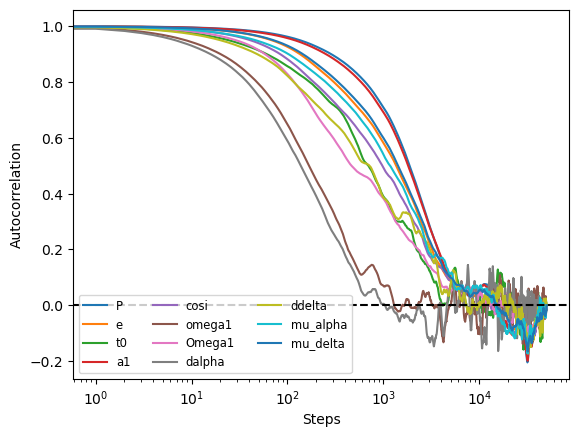

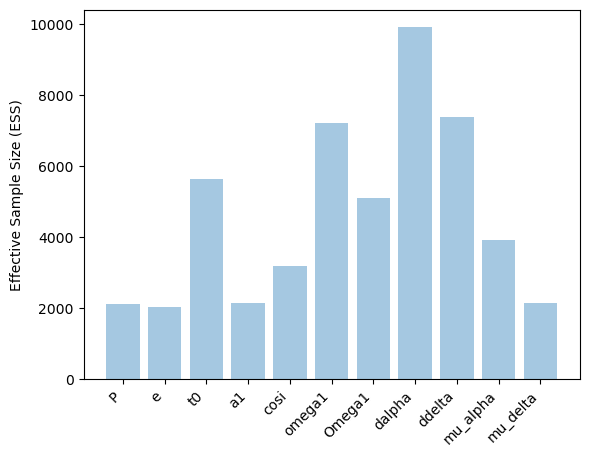

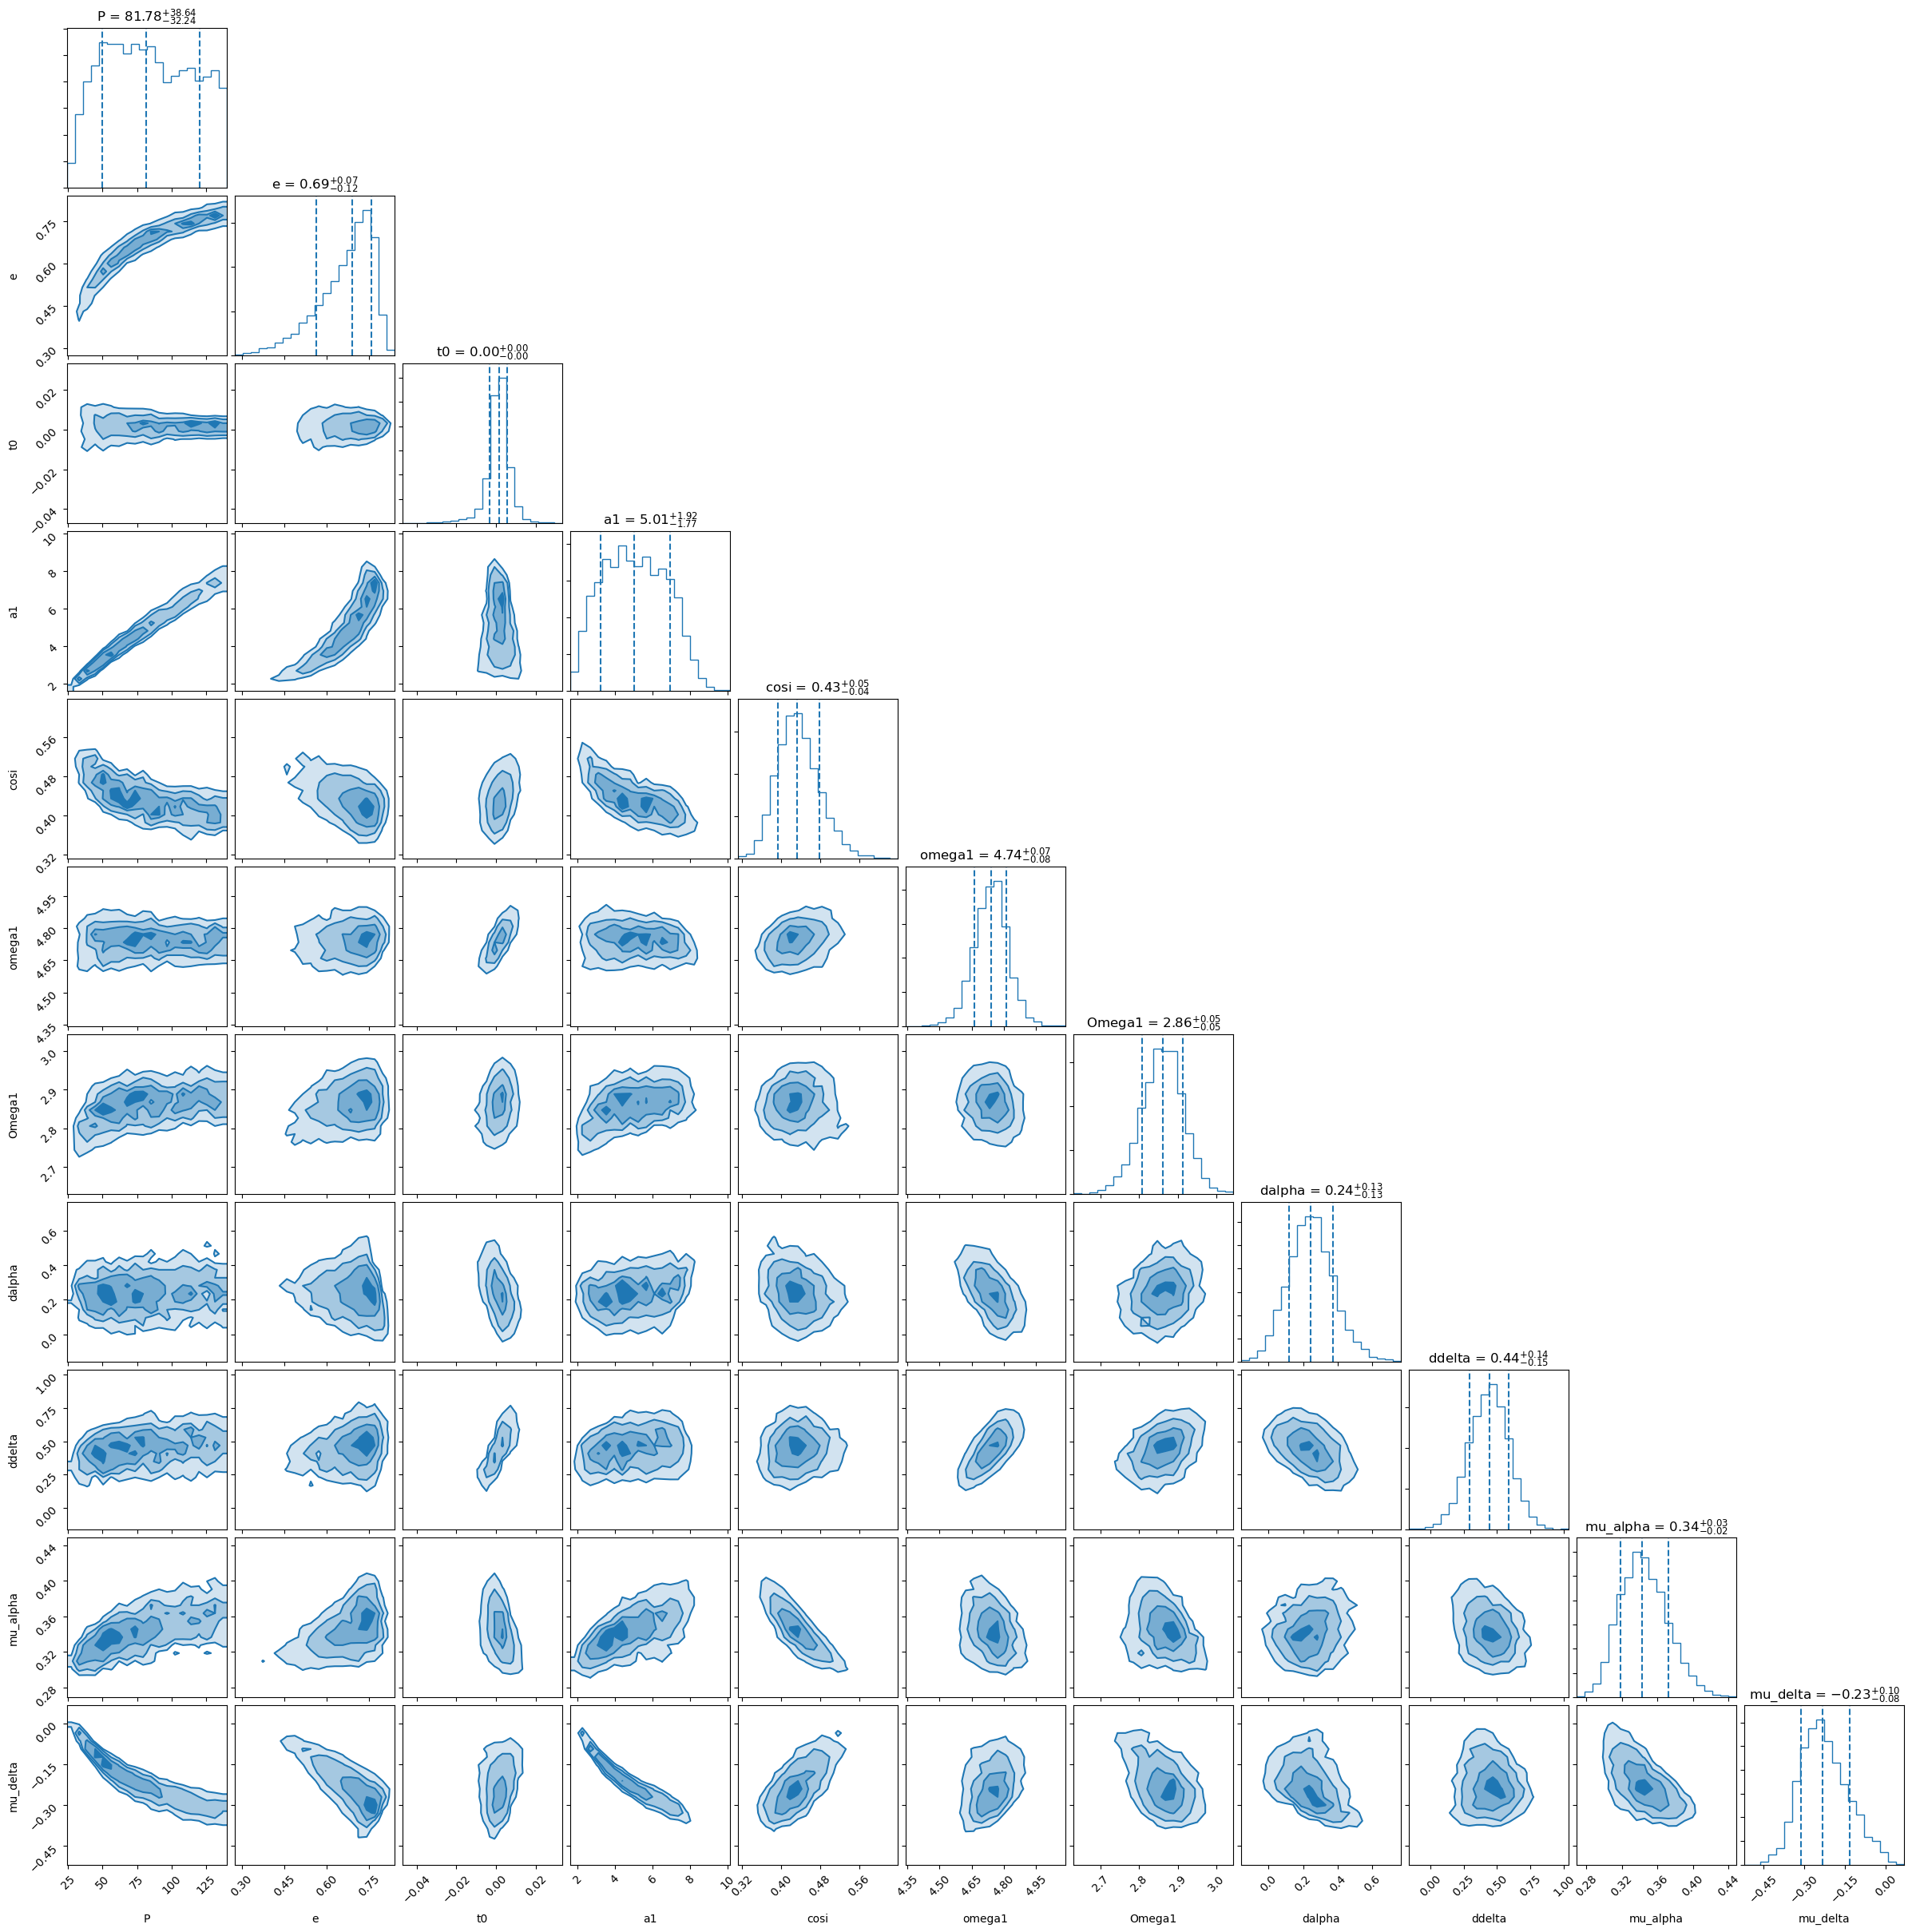

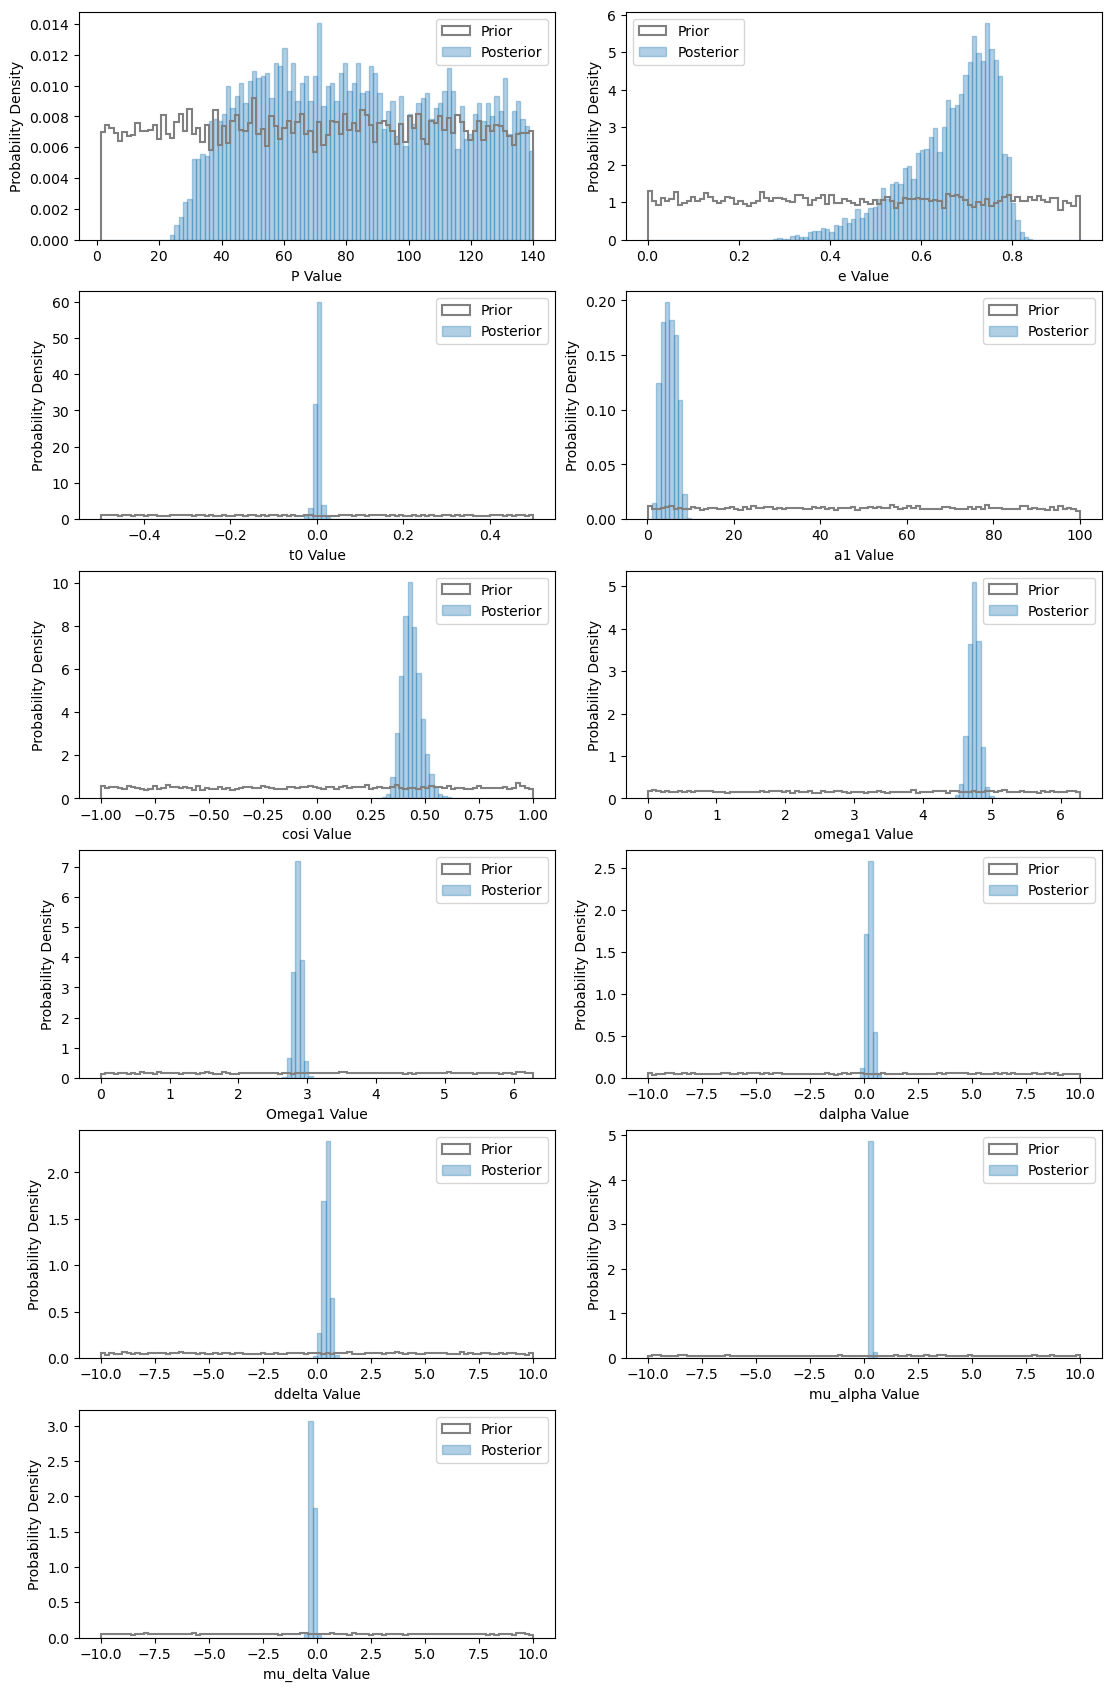

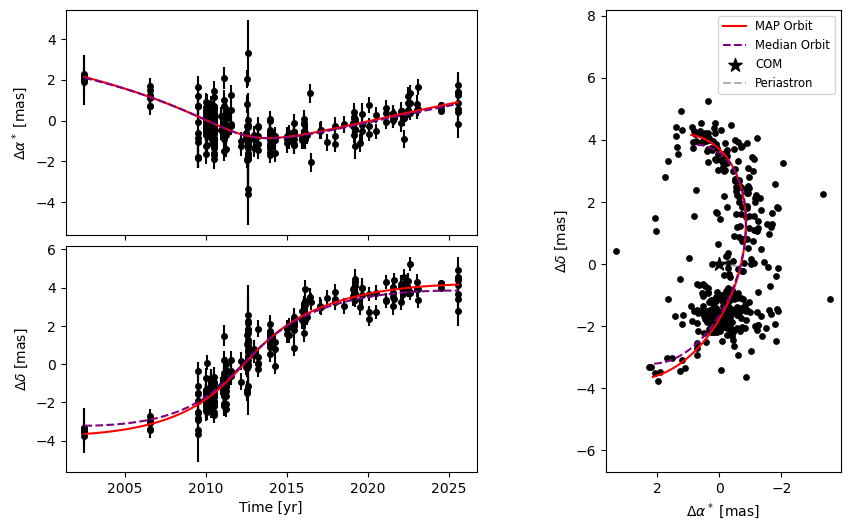

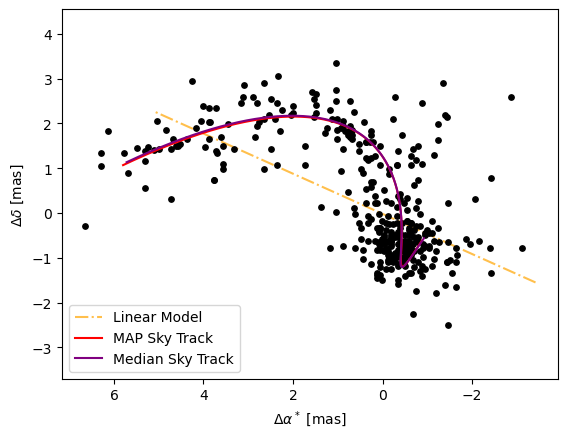

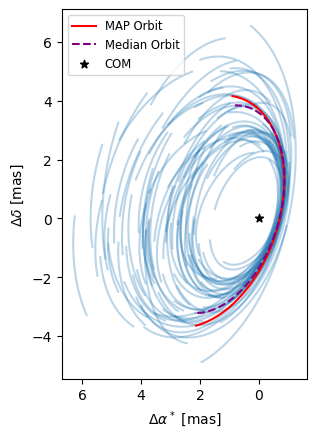

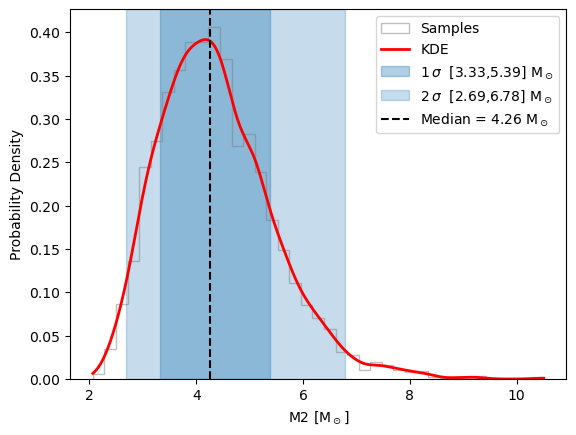

In [11]:
p.all_plots(results2,data)